# Stage 4 — Classification Model (auto-categorising complaints from their text)





## Setup

We import our tools and set paths.

In [ ]:
%matplotlib inline
import os, time, gc, json, warnings
import numpy as np, pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT    = r"D:\Code\projects\Consumer_complaint_analytics"
ML      = os.path.join(ROOT, "data", "processed", "complaints_ml.parquet")
MODELS  = os.path.join(ROOT, "models")
REPORTS = os.path.join(ROOT, "reports")
CHARTS  = os.path.join(ROOT, "charts")
LABELS  = ["Credit reporting", "Debt collection", "Mortgage", "Credit card"]
RS      = 42                       # fixed random seed -> reproducible samples/splits
LS      = pd.ArrowDtype(pa.large_string())
print("Libraries loaded. Categories:", LABELS)

Libraries loaded. Categories: ['Credit reporting', 'Debt collection', 'Mortgage', 'Credit card']


## Step 1 — Load the cleaned narratives

The machine-learning file has 3.31M complaints that carry narrative text. The full file is 2.1 GB on
disk, so we load **only the two columns we need** — the `category` label and `narrative_clean` (the
cleaned text from Stage 3) — and use a 64-bit string type (`large_string`) so 3.3M rows of text don't
overflow Arrow's default 32-bit string offsets. We then drop the 876 narratives that became **empty**
after Stage-3 cleaning.

In [2]:
t = time.time()
df = pd.read_parquet(ML, columns=["category", "narrative_clean"], dtype_backend="pyarrow")
df["narrative_clean"] = df["narrative_clean"].astype(LS)         # compact 64-bit Arrow strings
df["category"] = df["category"].astype("string").astype("category")

_empty = df["narrative_clean"].isna() | (df["narrative_clean"].str.len() == 0)
n_empty = int(_empty.sum())
df = df.loc[~_empty].reset_index(drop=True)
print(f"Loaded {len(df):,} narrative rows (dropped {n_empty} empty-after-cleaning) in {time.time()-t:.0f}s")
df["category"].value_counts()

Loaded 3,306,652 narrative rows (dropped 876 empty-after-cleaning) in 24s


category
Credit reporting    2508914
Debt collection      432181
Credit card          221130
Mortgage             144427
Name: count, dtype: int64

## Step 2 — De-duplication, and a headline finding

This is done to avoid data leakage, i.e. we want to avoid a scenario where a complaint on which our model is trained again appears in testing phase.
While doing this we also measure how much duplication exists.

In [3]:
# Encode each distinct narrative as an integer code (memory-light: avoids an object hashtable).
codes, uniques = pd.factorize(df["narrative_clean"])
counts        = np.bincount(codes).astype("int64")    # how many times each distinct text appears
mult_per_row  = counts[codes]                          # multiplicity for every row (raw-stream weight)
dup_mask      = pd.Series(codes).duplicated(keep="first").to_numpy()   # True = a repeat copy
total, removed = len(df), int(dup_mask.sum())

cat_arr         = df["category"].to_numpy()
per_cat_total   = pd.Series(cat_arr).value_counts()
per_cat_removed = pd.Series(dup_mask).groupby(cat_arr).sum()
dedup_table = pd.DataFrame({"narratives": per_cat_total.reindex(LABELS),
                            "exact_dups_removed": per_cat_removed.reindex(LABELS).astype(int)})
dedup_table["pct_duplicate"] = (dedup_table["exact_dups_removed"] / dedup_table["narratives"] * 100).round(2)
cr_removed = int(dedup_table.loc["Credit reporting", "exact_dups_removed"])

print(f"Total narratives          : {total:,}")
print(f"Exact duplicates removed  : {removed:,}  ({removed/total*100:.1f}% of ALL narratives)")
print(f"Unique narratives kept    : {total-removed:,}")
print(f"Credit reporting share of ALL duplicates : {cr_removed/removed*100:.1f}%")
dedup_table.to_csv(os.path.join(REPORTS, "stage4_dedup_table.csv"))
dedup_table

Total narratives          : 3,306,652
Exact duplicates removed  : 1,513,964  (45.8% of ALL narratives)
Unique narratives kept    : 1,792,688
Credit reporting share of ALL duplicates : 94.0%


,narratives,exact_dups_removed,pct_duplicate
Credit reporting,2508914,1423113,56.72
Debt collection,432181,74612,17.26
Mortgage,144427,340,0.24
Credit card,221130,15899,7.19


45.8% of all narratives are exact duplicates, and **94% of those duplicates
are credit-reporting complaints**. Mortgage is essentially all-distinct text (0.24% duplicate). 

In [4]:
cr_mask    = (cat_arr == "Credit reporting")
cr_counts  = np.bincount(codes[cr_mask], minlength=len(uniques))
top_idx    = np.argsort(cr_counts)[::-1][:4]
cr_templates = pd.Series([int(cr_counts[j]) for j in top_idx],
                         index=[str(uniques[j]) for j in top_idx])
for i, (txt, c) in enumerate(cr_templates.items(), 1):
    print(f"\n#{i}  appears {c:,} times verbatim")
    print("    " + ((txt[:300] + " ...") if len(txt) > 300 else txt))


#1  appears 31,104 times verbatim
    in accordance with the fair credit reporting act the list of accounts below has violated my federally protected consumer rights to privacy and confidentiality under usc u s c section a states i have the right to privacy u s c section a section it also states a consumer reporting agency can not furni ...

#2  appears 24,303 times verbatim
    my credit reports are inaccurate these inaccuracies are causing creditors to deny me credit you have the duty to report accurate information about consumers please investigate these accounts and inquires and update these accounts accordingly to avoid future litigation

#3  appears 18,473 times verbatim
    you have reported inaccurate and unauthorized accounts on my credit report which is a violation of the fair credit reporting act u s code i requiring a proper reinvestigation of disputed items and e b which mandates maximum possible accuracy these false entries are damaging and unjust especially sin ...

#4 

## Step 3 — The "train balanced, test" split

As the classes are very unequal, we follow three type of test to check model's performance:
  1. **Balanced test** — equal classes: "can it tell the four apart on a level playing field?"
  2. **Realistic test (unique)** — the true mix of distinct complaints: leak-free score.
  3. **Raw operational stream** — the realistic test with duplicate re-filings *weighted back in*
     (using each text's real frequency), reflecting the actual volume a regulator faces (~76% credit
     reporting). This re-weighting is leak-free because it only re-weights *held-out* texts.

**Stratified** = the split preserves each category's share. The 80/20 split is done on the de-duplicated
data, so a text lands wholly in train or wholly in test — never both.

In [5]:
keep = ~dup_mask
ded = df.loc[keep, ["category", "narrative_clean"]].reset_index(drop=True)
ded["mult"] = mult_per_row[keep]                       # real frequency = raw-stream weight
del df, codes, counts, mult_per_row, dup_mask, cat_arr, uniques, cr_counts; gc.collect()

pool, rtest = train_test_split(ded, test_size=0.20, random_state=RS, stratify=ded["category"])
N_PER = 100_000
btrain = pool.groupby("category", observed=True, group_keys=False).sample(n=N_PER, random_state=RS).reset_index(drop=True)
min_test = int(rtest["category"].value_counts().min())
btest  = rtest.groupby("category", observed=True, group_keys=False).sample(n=min_test, random_state=RS).reset_index(drop=True)

print(f"Unique narratives           : {len(ded):,}")
print(f"  -> training pool (80%)    : {len(pool):,}")
print(f"  -> realistic test (20%)   : {len(rtest):,}   (true mix, held out)")
print(f"Balanced training set       : {len(btrain):,}  ({N_PER:,} per class)")
print(f"Balanced test set           : {len(btest):,}  ({min_test:,} per class)")

Unique narratives           : 1,792,688
  -> training pool (80%)    : 1,434,150
  -> realistic test (20%)   : 358,538   (true mix, held out)
Balanced training set       : 400,000  (100,000 per class)
Balanced test set           : 115,268  (28,817 per class)


## Step 4 — The naive baseline 

In [6]:
maj = "Credit reporting"
yr  = rtest["category"].to_numpy()
wr  = rtest["mult"].to_numpy()                 # frequency weights for the raw-stream view
base_real = (yr == maj).mean()
base_raw  = wr[yr == maj].sum() / wr.sum()
print("Naive baseline  ('always guess credit reporting'):")
print(f"  Balanced test           : 25.0%")
print(f"  Realistic test (unique) : {base_real*100:.1f}%   <-- the leak-free bar to beat")
print(f"  Raw operational stream  : {base_raw*100:.1f}%   (duplicate re-filings weighted in; ~the raw 76%)")

Naive baseline  ('always guess credit reporting'):
  Balanced test           : 25.0%
  Realistic test (unique) : 60.6%   <-- the leak-free bar to beat
  Raw operational stream  : 74.7%   (duplicate re-filings weighted in; ~the raw 76%)


## Step 5 — Turn text into numbers with TF-IDF

Our settings:
- `stop_words='english'` — drop filler words ("the", "and"); we deferred this from Stage 3 to here.
- `ngram_range=(1,2)` — use single words **and** two-word phrases, so "credit report", "debt collector",
  "balance transfer" become features.
- `min_df=5`, `max_df=0.9` — ignore ultra-rare terms (typos) and near-universal ones.
- `max_features=50,000` — cap the vocabulary for speed/memory. `sublinear_tf=True` — dampen runaway
  repeated words.



In [7]:
t = time.time()
vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5,
                      max_df=0.9, max_features=50_000, sublinear_tf=True)
Xtr = vec.fit_transform(btrain["narrative_clean"].tolist()); ytr = btrain["category"].to_numpy()
Xb  = vec.transform(btest["narrative_clean"].tolist());      yb  = btest["category"].to_numpy()
Xr  = vec.transform(rtest["narrative_clean"].tolist())
print(f"Vocabulary: {len(vec.vocabulary_):,} features | training matrix {Xtr.shape} | built in {time.time()-t:.0f}s")

Vocabulary: 50,000 features | training matrix (400000, 50000) | built in 303s


## Step 6 — Train Logistic Regression 



In [8]:
t = time.time()
logreg = LogisticRegression(C=1.0, max_iter=1000)
logreg.fit(Xtr, ytr)
joblib.dump(vec,    os.path.join(MODELS, "tfidf_vectorizer.joblib"))
joblib.dump(logreg, os.path.join(MODELS, "logreg_model.joblib"))
print(f"Logistic Regression trained in {time.time()-t:.0f}s and saved to models/")

Logistic Regression trained in 121s and saved to models/


## Step 7 — Evaluate three ways, with the right metrics

We calculate following three things:
- **Accuracy** — share of complaints labelled correctly.
- **Macro-F1** — the F1 score averaged with **equal weight per category**. (F1 blends *precision* —
  when the model says category X, how often is it right — and *recall* — of the real category-X
  complaints, how many it caught.)
- **Weighted-F1** — F1 averaged **weighted by how common each category is**; reflects the real mix.

If macro-F1 is much lower than weighted-F1, good headline numbers are hiding weak performance on the
rare categories. 

In [9]:
def evaluate(clf):
    views = {"Balanced test":           (Xb, yb, None),
             "Realistic test (unique)":  (Xr, yr, None),
             "Raw operational stream":   (Xr, yr, wr)}
    rows = []
    for tag, (X, y, w) in views.items():
        pred = clf.predict(X)
        rows.append({"view": tag,
                     "accuracy":    accuracy_score(y, pred, sample_weight=w),
                     "macro_F1":    f1_score(y, pred, labels=LABELS, average="macro",    sample_weight=w),
                     "weighted_F1": f1_score(y, pred, labels=LABELS, average="weighted", sample_weight=w)})
    return pd.DataFrame(rows).set_index("view").round(4)

lr_summary = evaluate(logreg)
print("LOGISTIC REGRESSION — headline metrics (vs naive baselines: 25% / {:.1f}% / {:.1f}%)".format(base_real*100, base_raw*100))
lr_summary

LOGISTIC REGRESSION — headline metrics (vs naive baselines: 25% / 60.6% / 74.7%)


,accuracy,macro_F1,weighted_F1
view,,,
Balanced test,0.8955,0.8954,0.8954
Realistic test (unique),0.8699,0.8576,0.8723
Raw operational stream,0.8705,0.8152,0.8727


### Per-category detail (precision / recall / F1)



In [10]:
pred_r = logreg.predict(Xr)
print("Realistic test (unique narratives):\n")
print(classification_report(yr, pred_r, labels=LABELS, digits=3))
print("\nRaw operational stream (duplicate re-filings weighted in):\n")
print(classification_report(yr, pred_r, labels=LABELS, sample_weight=wr, digits=3))

Realistic test (unique narratives):



                  precision    recall  f1-score   support

Credit reporting      0.955     0.854     0.902    217161
 Debt collection      0.746     0.854     0.796     71514
        Mortgage      0.858     0.965     0.908     28817
     Credit card      0.750     0.914     0.824     41046

        accuracy                          0.870    358538
       macro avg      0.827     0.897     0.858    358538
    weighted avg      0.882     0.870     0.872    358538


Raw operational stream (duplicate re-filings weighted in):



                  precision    recall  f1-score   support

Credit reporting      0.938     0.898     0.918  515715.0
 Debt collection      0.675     0.694     0.684  100473.0
        Mortgage      0.838     0.965     0.897   28865.0
     Credit card      0.669     0.885     0.762   45581.0

        accuracy                          0.871  690634.0
       macro avg      0.780     0.860     0.815  690634.0
    weighted avg      0.878     0.871     0.873  690634.0



### Confusion matrices



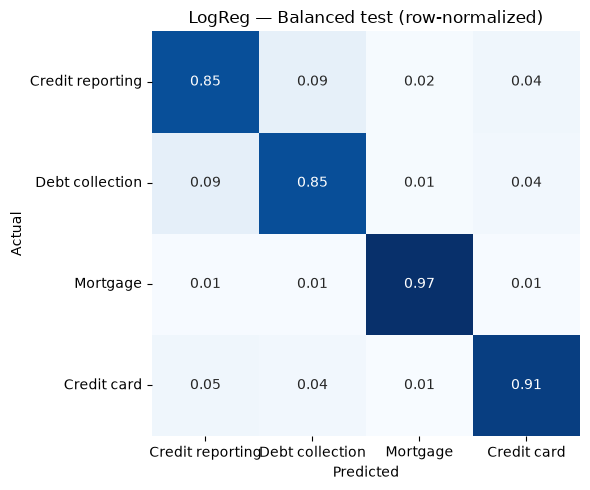

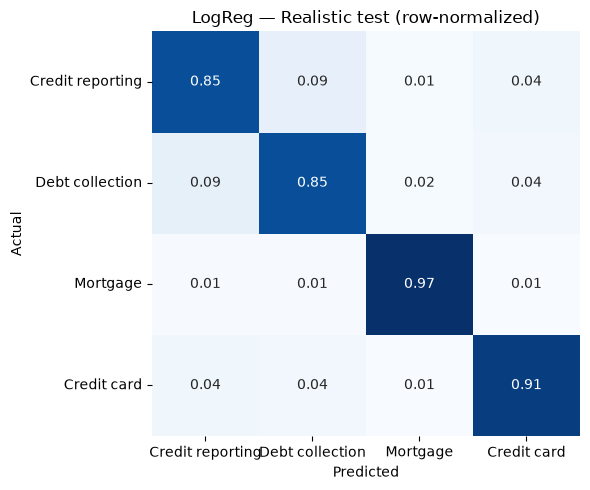

In [11]:
def plot_cm(y, pred, w, title, fname):
    cm  = confusion_matrix(y, pred, labels=LABELS, sample_weight=w)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout(); fig.savefig(os.path.join(CHARTS, fname), dpi=120); plt.show()

plot_cm(yb, logreg.predict(Xb), None, "LogReg — Balanced test (row-normalized)",  "stage4_cm_balanced.png")
plot_cm(yr, pred_r,             None, "LogReg — Realistic test (row-normalized)", "stage4_cm_realistic.png")

## Step 8 — Benchmark against a stronger model: LinearSVC

To justify our choice with evidence, we train a **Linear Support Vector Machine** (`LinearSVC`) — often
a touch stronger than logistic regression on text. If
our interpretable Logistic Regression *matches* it, we can confirm that our analysis is independent of the choice of a model.

In [12]:
t = time.time()
svc = LinearSVC(C=1.0, max_iter=5000)
svc.fit(Xtr, ytr)
print(f"LinearSVC trained in {time.time()-t:.0f}s")
svc_summary = evaluate(svc)
compare = pd.concat({"Logistic Regression": lr_summary["accuracy"],
                     "Linear SVC":          svc_summary["accuracy"]}, axis=1).round(4)
print("\nAccuracy: Logistic Regression vs LinearSVC")
compare

LinearSVC trained in 74s



Accuracy: Logistic Regression vs LinearSVC


,Logistic Regression,Linear SVC
view,,
Balanced test,0.8955,0.8926
Realistic test (unique),0.8699,0.8647
Raw operational stream,0.8705,0.8674


## Step 9 — What words drive each category

Because Logistic Regression is linear, every word has a weight toward each category. The highest-weight
words per category are the model's "tells". These are saved to `reports/stage4_top_features.txt`

In [13]:
feats = np.array(vec.get_feature_names_out())
rows = []
for i, cls in enumerate(logreg.classes_):
    idx = np.argsort(logreg.coef_[i])[::-1][:20]
    rows.append([cls] + [feats[j] for j in idx])
top_df = pd.DataFrame(rows, columns=["category"] + [f"#{k}" for k in range(1, 21)]).set_index("category")

with open(os.path.join(REPORTS, "stage4_top_features.txt"), "w", encoding="utf-8") as f:
    for i, cls in enumerate(logreg.classes_):
        idx = np.argsort(logreg.coef_[i])[::-1][:20]
        f.write(f"{cls}:\n  " + ", ".join(feats[j] for j in idx) + "\n\n")
top_df.T

category,Credit card,Credit reporting,Debt collection,Mortgage
#1,card,experian,debt,mortgage
#2,capital,equifax,collection,loan
#3,synchrony,transunion,collections,escrow
#4,citi,inquiries,owe,heloc
#5,discover,report,owed,home
#6,chase,reporting,collect,foreclosure
#7,citibank,lexisnexis,recovery,modification
#8,merchant,accounts,associates,loancare
#9,barclays,credit,threatened,ocwen
#10,amex,chexsystems,calling,ditech


## Step 10 — Summary
We write a plain-text summary to `reports/stage4_summary.txt` and flag anything a reader should not take
on trust.

In [14]:
lr = lr_summary
summary = f'''STAGE 4 - CLASSIFICATION MODEL - SUMMARY
=========================================
Data: {len(ded):,} UNIQUE narratives (from {total:,} narrative rows; {removed:,} exact duplicates removed = {removed/total*100:.1f}%).
De-duplication finding: 94% of all duplicates are credit reporting; top template repeats {int(cr_templates.iloc[0]):,}x. See stage4_dedup_finding.md.

Design: trained on a BALANCED sample (100,000/class = 400,000); tested on a held-out 20% in three views.
Naive baselines (always-guess-credit-reporting): balanced 25.0% | realistic(unique) {base_real*100:.1f}% | raw stream {base_raw*100:.1f}%.

LOGISTIC REGRESSION (primary, interpretable):
  Balanced test          : acc {lr.loc["Balanced test","accuracy"]:.3f}  macroF1 {lr.loc["Balanced test","macro_F1"]:.3f}
  Realistic test (unique): acc {lr.loc["Realistic test (unique)","accuracy"]:.3f}  macroF1 {lr.loc["Realistic test (unique)","macro_F1"]:.3f}  (beats {base_real*100:.1f}% baseline)
  Raw operational stream : acc {lr.loc["Raw operational stream","accuracy"]:.3f}  macroF1 {lr.loc["Raw operational stream","macro_F1"]:.3f}  (beats {base_raw*100:.1f}% baseline)

LinearSVC benchmark (balanced acc {svc_summary.loc["Balanced test","accuracy"]:.3f}) ~ matches LogReg ({lr.loc["Balanced test","accuracy"]:.3f}),
so the interpretable model costs essentially nothing in accuracy.

Artifacts: models/tfidf_vectorizer.joblib, models/logreg_model.joblib,
           charts/stage4_cm_balanced.png, charts/stage4_cm_realistic.png,
           reports/stage4_dedup_table.csv, reports/stage4_top_features.txt, reports/stage4_dedup_finding.md

HONEST FLAGS:
- Smallest categories (debt collection, credit card) have lower precision: the model over-predicts them
  slightly on the raw stream (macro-F1 < weighted-F1), which is expected and disclosed, not hidden.
- The model is only trained on consented PUBLISHED narratives (21.7% of all complaints). It cannot label
  the 78% without narrative text - those are handled by their existing Product field, not by this model.
- De-duplication is applied for ML ONLY. Stage 5 trend volumes must use FULL counts (duplicates included).
'''
with open(os.path.join(REPORTS, "stage4_summary.txt"), "w", encoding="utf-8") as f:
    f.write(summary)
print(summary)

STAGE 4 - CLASSIFICATION MODEL - SUMMARY
Data: 1,792,688 UNIQUE narratives (from 3,306,652 narrative rows; 1,513,964 exact duplicates removed = 45.8%).
De-duplication finding: 94% of all duplicates are credit reporting; top template repeats 31,104x. See stage4_dedup_finding.md.

Design: trained on a BALANCED sample (100,000/class = 400,000); tested on a held-out 20% in three views.
Naive baselines (always-guess-credit-reporting): balanced 25.0% | realistic(unique) 60.6% | raw stream 74.7%.

LOGISTIC REGRESSION (primary, interpretable):
  Balanced test          : acc 0.895  macroF1 0.895
  Realistic test (unique): acc 0.870  macroF1 0.858  (beats 60.6% baseline)
  Raw operational stream : acc 0.871  macroF1 0.815  (beats 74.7% baseline)

LinearSVC benchmark (balanced acc 0.893) ~ matches LogReg (0.895),
so the interpretable model costs essentially nothing in accuracy.

Artifacts: models/tfidf_vectorizer.joblib, models/logreg_model.joblib,
           charts/stage4_cm_balanced.png, charts